# Skin Lesion Classification with Deep Learning

Multi-class classification of dermatoscopic images into 7 diagnostic
categories using the HAM10000 dataset.

**Dataset:** HAM10000 — 10,015 dermatoscopic images, 7 classes  
**Framework:** PyTorch  
**Author:** [Syed Tahmed Ahmed]

> **Disclaimer:** This is an academic project built for learning purposes.
> It is not a medical device and must not be used for diagnosis.

---

## Table of Contents
1. Data Loading & Setup
2. Exploratory Data Analysis
3. Data Splitting
4. Preprocessing & Caching
5. Dataset & DataLoader
6. Baseline Model
7. Experiments
8. Evaluation
9. Explainability

## 0. Session Restore

**What:** Rebuild the full working state — imports, Drive, cached arrays,
transforms, datasets, and loaders — in one cell.

**Why:** Colab clears all variables on disconnect or restart. Consolidating
the setup into a single cell makes recovery one click instead of hunting
through the notebook. The caching cell in 4.1 is deliberately excluded,
since the arrays already exist on Drive.

In [2]:
# ============================================================
# SESSION RESTORE - run this single cell after any disconnect
# ============================================================

import os
import random
import json
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, recall_score, precision_score)

# ---- Drive ----
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/ham10000_project"
RESULTS_DIR = os.path.join(DRIVE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- Load cached arrays ----
cache = np.load(os.path.join(DRIVE_DIR, "cached_128.npz"))
X_train, y_train = cache['X_train'], cache['y_train']
X_val,   y_val   = cache['X_val'],   cache['y_val']
X_test,  y_test  = cache['X_test'],  cache['y_test']

train_df = pd.read_csv(os.path.join(DRIVE_DIR, "train_df.csv"))
val_df   = pd.read_csv(os.path.join(DRIVE_DIR, "val_df.csv"))
test_df  = pd.read_csv(os.path.join(DRIVE_DIR, "test_df.csv"))

# ---- Class mapping ----
classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

# ---- Transforms ----
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ---- Dataset ----
class SkinLesionDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        image = self.transform(self.X[idx])
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label


train_dataset = SkinLesionDataset(X_train, y_train, train_transform)
val_dataset   = SkinLesionDataset(X_val,   y_val,   eval_transform)
test_dataset  = SkinLesionDataset(X_test,  y_test,  eval_transform)

# ---- DataLoaders ----
BATCH_SIZE = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin = (device.type == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin)

print("Session restored.")
print("  Device :", device)
print("  Train  :", X_train.shape)
print("  Val    :", X_val.shape)
print("  Test   :", X_test.shape)

Mounted at /content/drive
Session restored.
  Device : cuda
  Train  : (6990, 128, 128, 3)
  Val    : (1509, 128, 128, 3)
  Test   : (1516, 128, 128, 3)


In [3]:
# ============================================================
# MODEL + TRAINING + EVALUATION DEFINITIONS
# Run after Session Restore
# ============================================================

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                epochs=20, patience=5, scheduler=None, checkpoint_name=None):

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(epochs):
        start = time.time()

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_loss, val_acc = running_loss / total, correct / total

        if scheduler is not None:
            scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            marker = "  <-- best"
            if checkpoint_name:
                torch.save(best_weights, os.path.join(DRIVE_DIR, checkpoint_name))
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
              f"{time.time()-start:.0f}s{marker}")

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping: no improvement for {patience} epochs.")
            break

    model.load_state_dict(best_weights)
    print(f"\nBest validation loss: {best_val_loss:.4f}")
    return model, history


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


print("Model and training definitions ready.")

Model and training definitions ready.


# **Download the HAM10000 dataset from Kaggle.**




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
print(path)

/kaggle/input/skin-cancer-mnist-ham10000


# Inspect Folder Structure

In [ ]:
import os

for item in os.listdir(path):
    print(item)

hmnist_8_8_RGB.csv
hmnist_28_28_RGB.csv
HAM10000_images_part_1
ham10000_images_part_1
hmnist_8_8_L.csv
HAM10000_images_part_2
ham10000_images_part_2
hmnist_28_28_L.csv
HAM10000_metadata.csv


# Load Metadata

In [ ]:
import pandas as pd

meta = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))

print("Shape:", meta.shape)
print()
print(meta.head())


Shape: (10015, 7)

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


# Images vs Lesions — Leakage Check

In [ ]:
print("Total images :", meta['image_id'].nunique())
print("Total lesions:", meta['lesion_id'].nunique())

Total images : 10015
Total lesions: 7470


**Class Distribution**

In [ ]:
print(meta['dx'].value_counts())


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


**Images per Lesion**

In [ ]:
print(meta['lesion_id'].value_counts().value_counts().sort_index())

count
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64


**Resolve Duplicate Image Folders**

In [ ]:
f1 = os.path.join(path, "HAM10000_images_part_1")
f2 = os.path.join(path, "ham10000_images_part_1")

print("HAM (uppercase):", len(os.listdir(f1)))
print("ham (lowercase):", len(os.listdir(f2)))

HAM (uppercase): 5000
ham (lowercase): 5000


**Confirm Duplicate Folders Are Identical**

In [ ]:
files1 = sorted(os.listdir(f1))
files2 = sorted(os.listdir(f2))

print("Identical:", files1 == files2)
print("First 3 in f1:", files1[:3])
print("First 3 in f2:", files2[:3])

Identical: True
First 3 in f1: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg']
First 3 in f2: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg']


# **path mapping:**

In [ ]:
import glob

# Build a lookup: image_id -> full file path
image_paths = {}

for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder_path = os.path.join(path, folder)
    for file in os.listdir(folder_path):
        image_id = file.replace(".jpg", "")
        image_paths[image_id] = os.path.join(folder_path, file)

print("Total images mapped:", len(image_paths))

# Attach the path to the metadata table
meta['path'] = meta['image_id'].map(image_paths)

# Check for any missing files
print("Missing paths:", meta['path'].isnull().sum())
print()
print(meta[['image_id', 'dx', 'path']].head())

Total images mapped: 10015
Missing paths: 0

       image_id   dx                                               path
0  ISIC_0027419  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
1  ISIC_0025030  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
2  ISIC_0026769  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
3  ISIC_0025661  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4  ISIC_0031633  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...


# **Visual Inspection of Each Class**

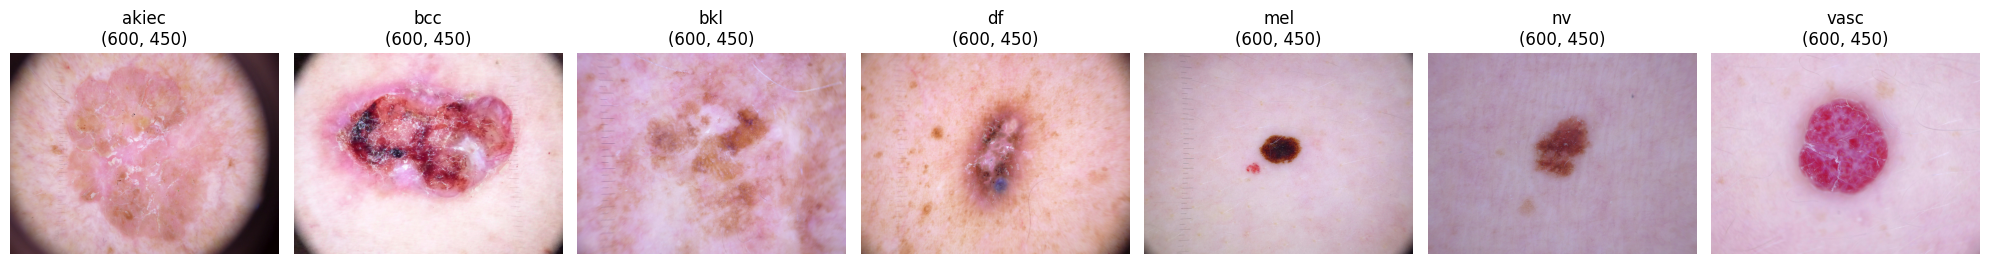

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(meta['dx'].unique())

fig, axes = plt.subplots(1, 7, figsize=(20, 4))

for ax, cls in zip(axes, classes):
    # Take the first image belonging to this class
    row = meta[meta['dx'] == cls].iloc[0]
    img = Image.open(row['path'])

    ax.imshow(img)
    ax.set_title(f"{cls}\n{img.size}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Class Imbalance Visualisation

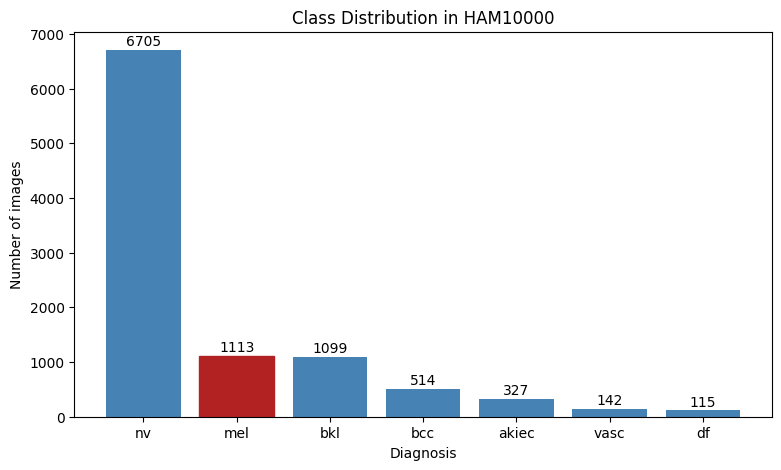

Majority class share: 66.95 %
Imbalance ratio     : 58.3 : 1


In [ ]:
counts = meta['dx'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color='steelblue')

# Highlight melanoma - the class that matters most clinically
bars[list(counts.index).index('mel')].set_color('firebrick')

plt.title("Class Distribution in HAM10000")
plt.xlabel("Diagnosis")
plt.ylabel("Number of images")

# Print the count above each bar
for i, v in enumerate(counts.values):
    plt.text(i, v + 80, str(v), ha='center')

plt.show()

print("Majority class share:", round(counts.max() / counts.sum() * 100, 2), "%")
print("Imbalance ratio     :", round(counts.max() / counts.min(), 1), ": 1")

# Patient and Lesion Metadata

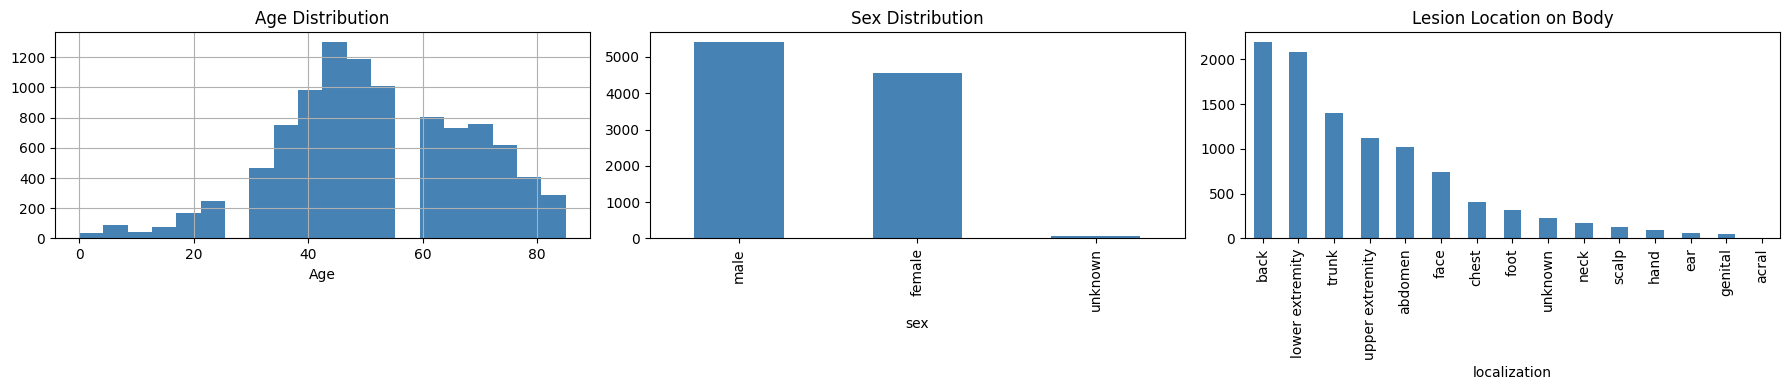

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Age distribution
meta['age'].hist(bins=20, ax=axes[0], color='steelblue')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Sex distribution
meta['sex'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Sex Distribution")

# Body location
meta['localization'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title("Lesion Location on Body")

plt.tight_layout()
plt.show()

# Check for missing values across all columns
print("Missing values per column:")
print(meta.isnull().sum())

# Data Splitting

In [ ]:
classes = sorted(meta['dx'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

meta['label'] = meta['dx'].map(class_to_idx)
print("Class mapping:")

for cls, idx in class_to_idx.items():
    print(f"  {idx} -> {cls}")

print()
print(meta[['image_id', 'dx', 'label']].head())

Class mapping:
  0 -> akiec
  1 -> bcc
  2 -> bkl
  3 -> df
  4 -> mel
  5 -> nv
  6 -> vasc

       image_id   dx  label
0  ISIC_0027419  bkl      2
1  ISIC_0025030  bkl      2
2  ISIC_0026769  bkl      2
3  ISIC_0025661  bkl      2
4  ISIC_0031633  bkl      2


# Group-Aware Train/Validation/Test Split

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(meta, groups=meta['lesion_id']))

train_df = meta.iloc[train_idx].reset_index(drop=True)
temp_df = meta.iloc[temp_idx].reset_index(drop=True)

# Second split: divide the 30% temp evenly into validation and test
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['lesion_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df), "images |", train_df['lesion_id'].nunique(), "lesions")
print("Val  :", len(val_df), "images |", val_df['lesion_id'].nunique(), "lesions")
print("Test :", len(test_df), "images |", test_df['lesion_id'].nunique(), "lesions")
print("Total:", len(train_df) + len(val_df) + len(test_df))

Train: 7002 images | 5229 lesions
Val  : 1519 images | 1120 lesions
Test : 1494 images | 1121 lesions
Total: 10015


# Verify No Lesion Leakage

In [ ]:
train_lesions = set(train_df['lesion_id'])
val_lesions = set(val_df['lesion_id'])
test_lesions = set(test_df['lesion_id'])

print("Train-Val overlap :", len(train_lesions & val_lesions))
print("Train-Test overlap:", len(train_lesions & test_lesions))
print("Val-Test overlap  :", len(val_lesions & test_lesions))

# Fail loudly if any overlap exists
assert len(train_lesions & val_lesions) == 0
assert len(train_lesions & test_lesions) == 0
assert len(val_lesions & test_lesions) == 0

print("\nNo leakage: all lesion groups are disjoint.")

Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0

No leakage: all lesion groups are disjoint.


# Verify Class Balance Across Splits

In [ ]:
dist = pd.DataFrame({
    'full':  meta['dx'].value_counts(normalize=True) * 100,
    'train': train_df['dx'].value_counts(normalize=True) * 100,
    'val':   val_df['dx'].value_counts(normalize=True) * 100,
    'test':  test_df['dx'].value_counts(normalize=True) * 100,
}).round(2)

print("Class share per split (%):")
print(dist)

print("\nAbsolute counts:")
counts_table = pd.DataFrame({
    'train': train_df['dx'].value_counts(),
    'val':   val_df['dx'].value_counts(),
    'test':  test_df['dx'].value_counts(),
})
print(counts_table)

Class share per split (%):
        full  train    val   test
dx                               
akiec   3.27   2.96   3.75   4.22
bcc     5.13   5.44   4.28   4.55
bkl    10.97  10.58  13.56  10.17
df      1.15   1.27   1.25   0.47
mel    11.11  11.00  10.27  12.52
nv     66.95  67.38  65.24  66.67
vasc    1.42   1.37   1.65   1.41

Absolute counts:
       train  val  test
dx                     
akiec    207   57    63
bcc      381   65    68
bkl      741  206   152
df        89   19     7
mel      770  156   187
nv      4718  991   996
vasc      96   25    21


# Reselect Split Seed for Rare-Class Coverage

In [ ]:
def make_splits(seed):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    tr_idx, tmp_idx = next(gss1.split(meta, groups=meta['lesion_id']))
    tr = meta.iloc[tr_idx].reset_index(drop=True)
    tmp = meta.iloc[tmp_idx].reset_index(drop=True)

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    v_idx, te_idx = next(gss2.split(tmp, groups=tmp['lesion_id']))
    return tr, tmp.iloc[v_idx].reset_index(drop=True), tmp.iloc[te_idx].reset_index(drop=True)


# Compare seeds on the minimum class count in val and test
print(f"{'seed':<6}{'min val':<10}{'min test':<10}{'df val':<9}{'df test'}")
for seed in range(0, 30):
    tr, v, te = make_splits(seed)
    vc, tc = v['dx'].value_counts(), te['dx'].value_counts()
    # Skip any seed where a class is entirely absent
    if len(vc) < 7 or len(tc) < 7:
        continue
    print(f"{seed:<6}{vc.min():<10}{tc.min():<10}{vc.get('df'):<9}{tc.get('df')}")

seed  min val   min test  df val   df test
0     18        19        18       19
1     12        18        12       18
2     13        18        13       19
3     8         14        8        17
4     9         13        9        13
5     18        20        18       20
6     12        16        15       16
7     11        17        11       21
8     14        15        14       15
9     16        16        26       19
10    12        20        15       20
11    14        14        14       14
12    15        16        15       17
13    20        16        20       16
14    16        26        16       26
15    12        9         12       9
16    11        18        11       28
17    23        12        24       12
18    12        14        12       14
19    15        20        15       22
20    22        17        23       17
21    11        8         11       8
22    18        21        18       26
23    8         13        8        13
24    18        16        18       22
25    18 

# Final Splits (seed = 5)

In [ ]:
SEED = 5

train_df, val_df, test_df = make_splits(SEED)

print("Train:", len(train_df), "images |", train_df['lesion_id'].nunique(), "lesions")
print("Val  :", len(val_df), "images |", val_df['lesion_id'].nunique(), "lesions")
print("Test :", len(test_df), "images |", test_df['lesion_id'].nunique(), "lesions")

# Re-verify no leakage with the new seed
assert not (set(train_df['lesion_id']) & set(val_df['lesion_id']))
assert not (set(train_df['lesion_id']) & set(test_df['lesion_id']))
assert not (set(val_df['lesion_id']) & set(test_df['lesion_id']))
print("\nLeakage check passed.")

print("\nAbsolute counts per class:")
print(pd.DataFrame({
    'train': train_df['dx'].value_counts(),
    'val':   val_df['dx'].value_counts(),
    'test':  test_df['dx'].value_counts(),
}))

Train: 6990 images | 5229 lesions
Val  : 1509 images | 1120 lesions
Test : 1516 images | 1121 lesions

Leakage check passed.

Absolute counts per class:
       train   val  test
dx                      
akiec    231    40    56
bcc      353    77    84
bkl      757   169   173
df        77    18    20
mel      771   165   177
nv      4719  1006   980
vasc      82    34    26


# Preprocessing and Caching
Resize and Cache Images as NumPy Arrays
Load all 10,015 JPEGs once, resize them to 128x128, and store
them as uint8 NumPy arrays alongside their labels.

In [ ]:
import numpy as np
from tqdm import tqdm

IMG_SIZE = 128

def cache_split(df, name):
    n = len(df)
    X = np.zeros((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    y = np.zeros(n, dtype=np.int64)

    for i, row in enumerate(tqdm(df.itertuples(), total=n, desc=name)):
        img = Image.open(row.path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        X[i] = np.array(img)
        y[i] = row.label

    return X, y


X_train, y_train = cache_split(train_df, "train")
X_val,   y_val   = cache_split(val_df,   "val")
X_test,  y_test  = cache_split(test_df,  "test")

print("\nShapes:")
print("  X_train:", X_train.shape, "|", round(X_train.nbytes / 1e6, 1), "MB")
print("  X_val  :", X_val.shape,   "|", round(X_val.nbytes / 1e6, 1), "MB")
print("  X_test :", X_test.shape,  "|", round(X_test.nbytes / 1e6, 1), "MB")
print("  Total  :", round((X_train.nbytes + X_val.nbytes + X_test.nbytes) / 1e6, 1), "MB")

test: 100%|██████████| 1516/1516 [00:24<00:00, 62.11it/s]


Shapes:
  X_train: (6990, 128, 128, 3) | 343.6 MB
  X_val  : (1509, 128, 128, 3) | 74.2 MB
  X_test : (1516, 128, 128, 3) | 74.5 MB
  Total  : 492.3 MB


# **Mount Google Drive**

Connect Google Drive to this Colab session and create a project .

**Why:** Colab wipes local storage when a session ends. Persisting the
cached arrays to Drive means later sessions load them in seconds instead
of re-decoding 10,015 JPEGs each time.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/ham10000_project"
os.makedirs(DRIVE_DIR, exist_ok=True)

print("Project folder ready:", DRIVE_DIR)

In [ ]:
try:
    print("X_train exists:", X_train.shape)
except NameError:
    print("X_train is GONE - need to re-run the caching cell")

# Persist Cached Arrays to Drive

**What:** Save the cached image arrays, labels, and split metadata to
Google Drive as compressed .npz files.

**Why:** This is the checkpoint that makes the project resumable. A future
session loads these in seconds rather than spending 15 minutes re-decoding
JPEGs. The split DataFrames are saved alongside so the exact same
train/val/test partition is reproduced every time.

In [ ]:
# Save the image arrays and labels
np.savez_compressed(
    os.path.join(DRIVE_DIR, "cached_128.npz"),
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)

# Save the split metadata so the exact partition can be reproduced
train_df.to_csv(os.path.join(DRIVE_DIR, "train_df.csv"), index=False)
val_df.to_csv(os.path.join(DRIVE_DIR, "val_df.csv"), index=False)
test_df.to_csv(os.path.join(DRIVE_DIR, "test_df.csv"), index=False)

print("Files saved:")
for f in sorted(os.listdir(DRIVE_DIR)):
    size_mb = os.path.getsize(os.path.join(DRIVE_DIR, f)) / 1e6
    print(f"  {f:<20} {size_mb:>8.1f} MB")

### 4.4 Fast Reload From Cache

**What:** Load the cached arrays and split metadata back from Drive.

**Why:** This is the entry point for every session after the first. Running
this single cell restores the full dataset state in seconds, skipping
sections 1 to 4.3 entirely.

In [ ]:
cache = np.load(os.path.join(DRIVE_DIR, "cached_128.npz"))

X_train, y_train = cache['X_train'], cache['y_train']
X_val,   y_val   = cache['X_val'],   cache['y_val']
X_test,  y_test  = cache['X_test'],  cache['y_test']

train_df = pd.read_csv(os.path.join(DRIVE_DIR, "train_df.csv"))
val_df   = pd.read_csv(os.path.join(DRIVE_DIR, "val_df.csv"))
test_df  = pd.read_csv(os.path.join(DRIVE_DIR, "test_df.csv"))

print("Loaded from cache:")
print("  X_train:", X_train.shape)
print("  X_val  :", X_val.shape)
print("  X_test :", X_test.shape)
print("  Labels :", np.bincount(y_train))

## 5. Dataset and DataLoader

### 5.1 Custom Dataset with Split-Specific Transforms

**What:** Define a Dataset that reads images from the in-memory arrays and
applies augmentation only when training.

**Why:** Reading from RAM removes the disk I/O bottleneck entirely.
Augmentation (flips, rotations, colour jitter) exposes the model to varied
views of the same lesion, which matters most for the rare classes where
only 77 training images exist. Validation and test use deterministic
transforms so their scores stay comparable across experiments.

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ImageNet statistics - required later for pretrained models
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class SkinLesionDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        image = self.transform(self.X[idx])
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label


train_dataset = SkinLesionDataset(X_train, y_train, train_transform)
val_dataset   = SkinLesionDataset(X_val,   y_val,   eval_transform)
test_dataset  = SkinLesionDataset(X_test,  y_test,  eval_transform)

print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

# Inspect one sample
img, label = train_dataset[0]
print("Image tensor:", img.shape, "| dtype:", img.dtype)
print("Value range :", round(img.min().item(), 2), "to", round(img.max().item(), 2))
print("Label       :", label.item(), "->", idx_to_class[label.item()])

Dataset sizes: 6990 1509 1516
Image tensor: torch.Size([3, 128, 128]) | dtype: torch.float32
Value range : -1.98 to 2.64
Label       : 2 -> bkl


### 5.2 Visualise Augmentation Effects

**What:** Display the same training image passed through the augmentation
pipeline several times.

**Why:** Augmentation is easy to get wrong silently — too weak and it does
nothing, too aggressive and it destroys the diagnostic features. Seeing
the variations confirms the transforms produce plausible alternative views
of the same lesion rather than unrecognisable images.

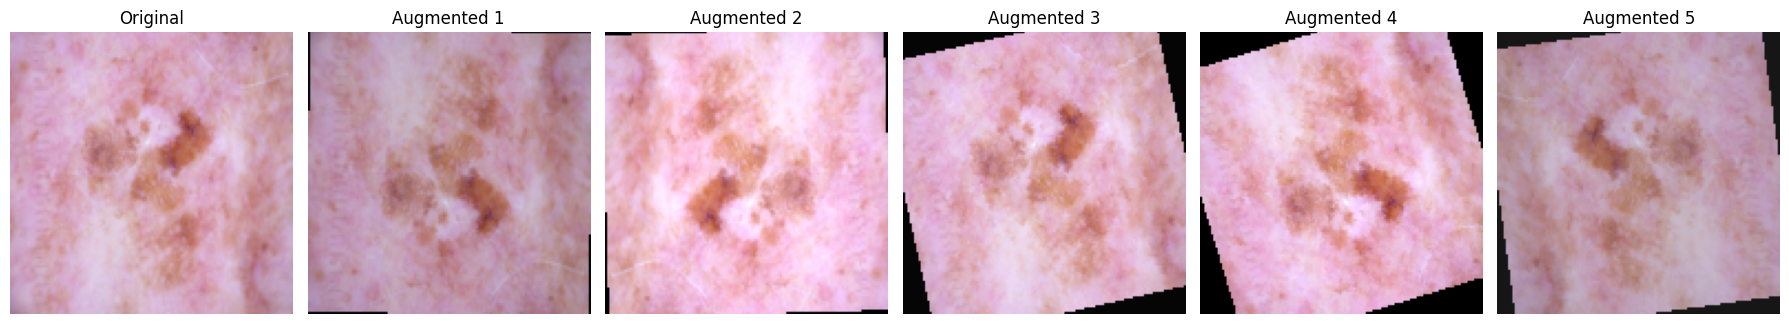

In [4]:
def denormalize(tensor):
    """Reverse the normalisation so the image can be displayed."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))

# Original, unaugmented
axes[0].imshow(X_train[0])
axes[0].set_title("Original")
axes[0].axis('off')

# Five augmented versions of the same image
for i in range(1, 6):
    img, _ = train_dataset[0]
    axes[i].imshow(denormalize(img))
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 5.3 DataLoaders

**What:** Wrap each Dataset in a DataLoader with batching and shuffling.

**Why:** DataLoader feeds the model in batches rather than one image at a
time, which is far more efficient on GPU. Training data is shuffled so
each epoch sees a different ordering — without this the model could learn
the sequence rather than the content. Validation and test are never
shuffled, keeping their evaluation order fixed and reproducible.

In [5]:
BATCH_SIZE = 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

pin = (device.type == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin)

print("Batches per epoch - train:", len(train_loader),
      "| val:", len(val_loader), "| test:", len(test_loader))

# Verify one batch
images, labels = next(iter(train_loader))
print("\nBatch shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels in batch:", labels.tolist())

Device: cuda
Batches per epoch - train: 219 | val: 48 | test: 48

Batch shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])
Labels in batch: [5, 5, 5, 5, 5, 5, 4, 1, 5, 2, 5, 5, 2, 2, 5, 5, 2, 5, 4, 5, 5, 4, 5, 5, 5, 5, 4, 5, 5, 0, 5, 5]


In [6]:
classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
print(idx_to_class)

{0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


In [15]:
for name in ['BaselineCNN', 'train_model', 'get_predictions', 'evaluate_full', 'set_seed']:
    print(f"{name:20s}", "OK" if name in globals() else "MISSING")

BaselineCNN          OK
train_model          OK
get_predictions      OK
evaluate_full        OK
set_seed             OK


In [14]:
import random
import json
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, recall_score, precision_score)

def set_seed(seed=42):
    """Fix all sources of randomness for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


RESULTS_DIR = os.path.join(DRIVE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)


def evaluate_full(model, loader, split_name="val"):
    """Return every metric we care about, per class and overall."""
    y_true, y_pred = get_predictions(model, loader)

    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    return {
        'split': split_name,
        'accuracy': float((y_true == y_pred).mean()),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'per_class_recall': {c: float(r) for c, r in zip(classes, per_class_recall)},
        'per_class_precision': {c: float(p) for c, p in zip(classes, per_class_precision)},
        'per_class_f1': {c: float(f) for c, f in zip(classes, per_class_f1)},
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }


def log_experiment(exp_id, name, config, results, history=None):
    """Save one experiment's full record to disk as JSON."""
    record = {
        'exp_id': exp_id,
        'name': name,
        'config': config,
        'results': results,
        'history': history,
    }
    path = os.path.join(RESULTS_DIR, f"exp_{exp_id:02d}_{name}.json")
    with open(path, 'w') as f:
        json.dump(record, f, indent=2)
    print(f"Logged to {path}")
    return record


set_seed(42)
print("Reproducibility setup ready.")

Reproducibility setup ready.


In [13]:
baseline = BaselineCNN(num_classes=7).to(device)
images, labels = next(iter(train_loader))
out = baseline(images.to(device))

### 7.2 Experiment 2 — Class-Weighted Loss

**What:** Retrain the same baseline architecture, but weight the loss
inversely to class frequency so errors on rare classes cost more.

**Why:** The baseline learned that predicting nv is almost always safe,
because every class contributes equally to the loss regardless of how rare
it is. Inverse-frequency weighting makes a mistake on df cost roughly 62
times more than one on nv, forcing the model to actually learn the minority
classes. Overall accuracy is expected to fall — the metrics that should
improve are macro F1 and melanoma recall.

In [16]:
set_seed(42)

# Inverse-frequency weights: total / (n_classes * class_count)
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(classes) * class_counts)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for c, n, w in zip(classes, class_counts, class_weights):
    print(f"  {c:<6} n={n:<5} weight={w:.2f}")
print()

# Same architecture, same optimizer - only the loss changes
model_w = BaselineCNN(num_classes=7).to(device)
criterion_w = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer_w = optim.Adam(model_w.parameters(), lr=0.001)

model_w, history_w = train_model(
    model=model_w,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_w,
    optimizer=optimizer_w,
    epochs=20,
    patience=5,
    checkpoint_name="exp2_weighted_cnn.pt",
)

Class weights:
  akiec  n=231   weight=4.32
  bcc    n=353   weight=2.83
  bkl    n=757   weight=1.32
  df     n=77    weight=12.97
  mel    n=771   weight=1.30
  nv     n=4719  weight=0.21
  vasc   n=82    weight=12.18

Epoch  1/20 | train loss 1.7681 acc 0.4044 | val loss 1.8741 acc 0.2478 | 15s  <-- best
Epoch  2/20 | train loss 1.6219 acc 0.4243 | val loss 2.0498 acc 0.2704 | 12s
Epoch  3/20 | train loss 1.6106 acc 0.4652 | val loss 1.3411 acc 0.4751 | 11s  <-- best
Epoch  4/20 | train loss 1.5251 acc 0.4625 | val loss 1.0941 acc 0.5467 | 12s  <-- best
Epoch  5/20 | train loss 1.5027 acc 0.4787 | val loss 1.3147 acc 0.4785 | 13s
Epoch  6/20 | train loss 1.5016 acc 0.4775 | val loss 1.2499 acc 0.5063 | 13s
Epoch  7/20 | train loss 1.4737 acc 0.4841 | val loss 1.0722 acc 0.5732 | 13s  <-- best
Epoch  8/20 | train loss 1.4809 acc 0.4838 | val loss 1.2520 acc 0.5593 | 13s
Epoch  9/20 | train loss 1.4370 acc 0.5053 | val loss 1.2536 acc 0.5036 | 12s
Epoch 10/20 | train loss 1.4168 acc 0

In [17]:
results_exp2 = evaluate_full(model_w, val_loader, "val")

print("Experiment 2 - Class-Weighted CNN\n")
print(f"Accuracy    : {results_exp2['accuracy']:.3f}")
print(f"Macro F1    : {results_exp2['macro_f1']:.3f}")
print(f"Weighted F1 : {results_exp2['weighted_f1']:.3f}")
print(f"Macro Recall: {results_exp2['macro_recall']:.3f}")

print("\nPer-class recall (Exp1 -> Exp2):")
exp1_recall = {'akiec': 0.100, 'bcc': 0.532, 'bkl': 0.355, 'df': 0.000,
               'mel': 0.236, 'nv': 0.957, 'vasc': 0.529}

for c in classes:
    old = exp1_recall[c]
    new = results_exp2['per_class_recall'][c]
    arrow = "up" if new > old else "down"
    print(f"  {c:<6} {old:.3f} -> {new:.3f}   ({arrow} {abs(new-old):.3f})")

Experiment 2 - Class-Weighted CNN

Accuracy    : 0.573
Macro F1    : 0.395
Weighted F1 : 0.614
Macro Recall: 0.491

Per-class recall (Exp1 -> Exp2):
  akiec  0.100 -> 0.400   (up 0.300)
  bcc    0.532 -> 0.390   (down 0.142)
  bkl    0.355 -> 0.296   (down 0.059)
  df     0.000 -> 0.333   (up 0.333)
  mel    0.236 -> 0.624   (up 0.388)
  nv     0.957 -> 0.630   (down 0.327)
  vasc   0.529 -> 0.765   (up 0.236)


In [19]:
log_experiment(
    exp_id=2,
    name="weighted_cnn",
    config={
        'architecture': 'BaselineCNN',
        'pretrained': False,
        'class_weights': 'inverse frequency',
        'optimizer': 'Adam',
        'lr': 0.001,
        'batch_size': 32,
        'epochs_run': len(history_w['train_loss']),
        'seed': 42,
    },
    results=results_exp2,
    history=history_w,
)


Logged to /content/drive/MyDrive/ham10000_project/results/exp_02_weighted_cnn.json


{'exp_id': 2,
 'name': 'weighted_cnn',
 'config': {'architecture': 'BaselineCNN',
  'pretrained': False,
  'class_weights': 'inverse frequency',
  'optimizer': 'Adam',
  'lr': 0.001,
  'batch_size': 32,
  'epochs_run': 12,
  'seed': 42},
 'results': {'split': 'val',
  'accuracy': 0.5732273028495692,
  'macro_f1': 0.3946798996597887,
  'weighted_f1': 0.6144365627518543,
  'macro_recall': 0.491138386511076,
  'per_class_recall': {'akiec': 0.4,
   'bcc': 0.38961038961038963,
   'bkl': 0.2958579881656805,
   'df': 0.3333333333333333,
   'mel': 0.6242424242424243,
   'nv': 0.6302186878727635,
   'vasc': 0.7647058823529411},
  'per_class_precision': {'akiec': 0.20512820512820512,
   'bcc': 0.2803738317757009,
   'bkl': 0.37593984962406013,
   'df': 0.08695652173913043,
   'mel': 0.2791327913279133,
   'nv': 0.9122302158273381,
   'vasc': 0.4482758620689655},
  'per_class_f1': {'akiec': 0.2711864406779661,
   'bcc': 0.32608695652173914,
   'bkl': 0.33112582781456956,
   'df': 0.13793103448275

In [20]:
experiments = pd.DataFrame([
    {
        'Exp': 1,
        'Model': 'Baseline CNN',
        'Changes': 'from scratch, no class weights',
        'Accuracy': 0.746,
        'Macro F1': 0.411,
        'mel Recall': 0.236,
        'df Recall': 0.000,
        'Result': 'majority-class bias; misses melanoma',
    },
    {
        'Exp': 2,
        'Model': 'Baseline CNN',
        'Changes': '+ class weights',
        'Accuracy': round(results_exp2['accuracy'], 3),
        'Macro F1': round(results_exp2['macro_f1'], 3),
        'mel Recall': round(results_exp2['per_class_recall']['mel'], 3),
        'df Recall': round(results_exp2['per_class_recall']['df'], 3),
        'Result': 'mel recall up 2.6x; precision cost',
    },
])

# Persist so a restart no longer loses the table
experiments.to_csv(os.path.join(RESULTS_DIR, "experiments.csv"), index=False)

print(experiments.to_string(index=False))

 Exp        Model                        Changes  Accuracy  Macro F1  mel Recall  df Recall                               Result
   1 Baseline CNN from scratch, no class weights     0.746     0.411       0.236      0.000 majority-class bias; misses melanoma
   2 Baseline CNN                + class weights     0.573     0.395       0.624      0.333   mel recall up 2.6x; precision cost


In [21]:
experiments = pd.read_csv(os.path.join(RESULTS_DIR, "experiments.csv"))

### 7.3 Experiment 3 — ResNet18 Transfer Learning

**What:** Replace the from-scratch CNN with an ImageNet-pretrained ResNet18,
fine-tuned end to end at a lower learning rate, keeping the class weights
from Experiment 2.

**Why:** Experiments 1 and 2 showed the same underlying problem from two
directions — the model's features are too weak to separate mel from nv, so
it defaults to whichever class the loss pushes it toward. ResNet18 arrives
already knowing how to detect edges, texture and colour structure from 1.4
million images, which 6,990 images cannot teach from scratch. The learning
rate drops to 1e-4 because large steps would destroy those pretrained
weights before they can be adapted.

In [22]:
from torchvision import models

set_seed(42)

# Load ImageNet-pretrained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace the final layer: ImageNet has 1000 classes, we have 7
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 7)
resnet = resnet.to(device)

print("Original fc input features:", num_features)
print("Total parameters:", f"{sum(p.numel() for p in resnet.parameters()):,}")

criterion_r = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer_r = optim.Adam(resnet.parameters(), lr=1e-4)

resnet, history_r = train_model(
    model=resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_r,
    optimizer=optimizer_r,
    epochs=20,
    patience=5,
    checkpoint_name="exp3_resnet18.pt",
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 95.6MB/s]


Original fc input features: 512
Total parameters: 11,180,103
Epoch  1/20 | train loss 1.2600 acc 0.5402 | val loss 0.9020 acc 0.6561 | 15s  <-- best
Epoch  2/20 | train loss 0.9130 acc 0.6621 | val loss 0.8469 acc 0.6408 | 14s  <-- best
Epoch  3/20 | train loss 0.7626 acc 0.6941 | val loss 0.7460 acc 0.6839 | 14s  <-- best
Epoch  4/20 | train loss 0.6967 acc 0.7216 | val loss 0.7830 acc 0.6793 | 14s
Epoch  5/20 | train loss 0.6294 acc 0.7288 | val loss 0.8763 acc 0.6528 | 14s
Epoch  6/20 | train loss 0.5937 acc 0.7448 | val loss 0.8393 acc 0.6587 | 13s
Epoch  7/20 | train loss 0.5791 acc 0.7425 | val loss 0.7959 acc 0.6826 | 13s
Epoch  8/20 | train loss 0.5176 acc 0.7675 | val loss 0.6406 acc 0.7442 | 14s  <-- best
Epoch  9/20 | train loss 0.4402 acc 0.7933 | val loss 0.7976 acc 0.7025 | 14s
Epoch 10/20 | train loss 0.4299 acc 0.7936 | val loss 0.7184 acc 0.7316 | 14s
Epoch 11/20 | train loss 0.4457 acc 0.8072 | val loss 0.7287 acc 0.7356 | 13s
Epoch 12/20 | train loss 0.4475 acc 0.789

In [23]:
results_exp3 = evaluate_full(resnet, val_loader, "val")

print("Experiment 3 - ResNet18 + class weights\n")
print(f"Accuracy    : {results_exp3['accuracy']:.3f}")
print(f"Macro F1    : {results_exp3['macro_f1']:.3f}")
print(f"Weighted F1 : {results_exp3['weighted_f1']:.3f}")
print(f"Macro Recall: {results_exp3['macro_recall']:.3f}")

print(f"\n{'class':<8}{'recall':>18}{'precision':>20}")
print(f"{'':8}{'Exp2 -> Exp3':>18}{'Exp2 -> Exp3':>20}")
print("-" * 48)

for c in classes:
    r_old = results_exp2['per_class_recall'][c]
    r_new = results_exp3['per_class_recall'][c]
    p_old = results_exp2['per_class_precision'][c]
    p_new = results_exp3['per_class_precision'][c]
    print(f"{c:<8}{r_old:>8.3f} ->{r_new:>7.3f}{p_old:>10.3f} ->{p_new:>9.3f}")

Experiment 3 - ResNet18 + class weights

Accuracy    : 0.744
Macro F1    : 0.593
Weighted F1 : 0.762
Macro Recall: 0.662

class               recall           precision
              Exp2 -> Exp3        Exp2 -> Exp3
------------------------------------------------
akiec      0.400 ->  0.425     0.205 ->    0.321
bcc        0.390 ->  0.688     0.280 ->    0.736
bkl        0.296 ->  0.533     0.376 ->    0.604
df         0.333 ->  0.611     0.087 ->    0.262
mel        0.624 ->  0.655     0.279 ->    0.393
nv         0.630 ->  0.808     0.912 ->    0.931
vasc       0.765 ->  0.912     0.448 ->    0.689


In [24]:
log_experiment(
    exp_id=3,
    name="resnet18_weighted",
    config={
        'architecture': 'ResNet18',
        'pretrained': 'ImageNet1K_V1',
        'fine_tuning': 'full network',
        'class_weights': 'inverse frequency',
        'optimizer': 'Adam',
        'lr': 1e-4,
        'batch_size': 32,
        'epochs_run': len(history_r['train_loss']),
        'seed': 42,
    },
    results=results_exp3,
    history=history_r,
)

experiments = pd.concat([experiments, pd.DataFrame([{
    'Exp': 3,
    'Model': 'ResNet18',
    'Changes': '+ pretrained, lr 1e-4',
    'Accuracy': round(results_exp3['accuracy'], 3),
    'Macro F1': round(results_exp3['macro_f1'], 3),
    'mel Recall': round(results_exp3['per_class_recall']['mel'], 3),
    'df Recall': round(results_exp3['per_class_recall']['df'], 3),
    'Result': 'all classes improved on both metrics',
}])], ignore_index=True)

experiments.to_csv(os.path.join(RESULTS_DIR, "experiments.csv"), index=False)
print(experiments.to_string(index=False))

Logged to /content/drive/MyDrive/ham10000_project/results/exp_03_resnet18_weighted.json
 Exp        Model                        Changes  Accuracy  Macro F1  mel Recall  df Recall                               Result
   1 Baseline CNN from scratch, no class weights     0.746     0.411       0.236      0.000 majority-class bias; misses melanoma
   2 Baseline CNN                + class weights     0.573     0.395       0.624      0.333   mel recall up 2.6x; precision cost
   3     ResNet18          + pretrained, lr 1e-4     0.744     0.593       0.655      0.611 all classes improved on both metrics


### 7.4 Experiment 4 — Learning Rate Scheduling

**What:** Repeat Experiment 3 with ReduceLROnPlateau, halving the learning
rate whenever validation loss stalls for two epochs.

**Why:** Experiment 3's validation loss oscillated — it reached 0.746 at
epoch 3, then worsened to 0.876 by epoch 5. That pattern means the steps
are too large near the optimum, so the model repeatedly overshoots.
Shrinking the step size as progress slows lets it settle into a minimum it
was previously stepping past. Patience is raised to 7 so early stopping
does not fire before the reduced rates have a chance to help.


In [25]:
set_seed(42)

resnet_sched = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_sched.fc = nn.Linear(resnet_sched.fc.in_features, 7)
resnet_sched = resnet_sched.to(device)

criterion_s = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer_s = optim.Adam(resnet_sched.parameters(), lr=1e-4)

scheduler_s = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s, mode='min', factor=0.5, patience=2
)

resnet_sched, history_s = train_model(
    model=resnet_sched,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_s,
    optimizer=optimizer_s,
    epochs=30,
    patience=7,
    scheduler=scheduler_s,
    checkpoint_name="exp4_resnet18_sched.pt",
)

Epoch  1/30 | train loss 1.2600 acc 0.5402 | val loss 0.9020 acc 0.6561 | 20s  <-- best
Epoch  2/30 | train loss 0.9130 acc 0.6621 | val loss 0.8469 acc 0.6408 | 13s  <-- best
Epoch  3/30 | train loss 0.7626 acc 0.6941 | val loss 0.7460 acc 0.6839 | 14s  <-- best
Epoch  4/30 | train loss 0.6967 acc 0.7216 | val loss 0.7830 acc 0.6793 | 14s
Epoch  5/30 | train loss 0.6294 acc 0.7288 | val loss 0.8763 acc 0.6528 | 14s
Epoch  6/30 | train loss 0.5937 acc 0.7448 | val loss 0.8393 acc 0.6587 | 13s
Epoch  7/30 | train loss 0.4967 acc 0.7658 | val loss 0.6813 acc 0.7283 | 13s  <-- best
Epoch  8/30 | train loss 0.4024 acc 0.8019 | val loss 0.6264 acc 0.7555 | 15s  <-- best
Epoch  9/30 | train loss 0.3824 acc 0.8100 | val loss 0.7042 acc 0.7362 | 14s
Epoch 10/30 | train loss 0.3514 acc 0.8170 | val loss 0.6865 acc 0.7402 | 14s
Epoch 11/30 | train loss 0.3307 acc 0.8335 | val loss 0.6356 acc 0.7800 | 13s
Epoch 12/30 | train loss 0.3010 acc 0.8433 | val loss 0.6631 acc 0.7575 | 13s
Epoch 13/30 | 

In [26]:
results_exp4 = evaluate_full(resnet_sched, val_loader, "val")

print("Experiment 4 - ResNet18 + LR scheduler\n")
print(f"Accuracy    : {results_exp4['accuracy']:.3f}   (Exp3: {results_exp3['accuracy']:.3f})")
print(f"Macro F1    : {results_exp4['macro_f1']:.3f}   (Exp3: {results_exp3['macro_f1']:.3f})")
print(f"Macro Recall: {results_exp4['macro_recall']:.3f}   (Exp3: {results_exp3['macro_recall']:.3f})")

print(f"\n{'class':<8}{'recall':>18}{'precision':>20}")
print(f"{'':8}{'Exp3 -> Exp4':>18}{'Exp3 -> Exp4':>20}")
print("-" * 48)

for c in classes:
    r_old = results_exp3['per_class_recall'][c]
    r_new = results_exp4['per_class_recall'][c]
    p_old = results_exp3['per_class_precision'][c]
    p_new = results_exp4['per_class_precision'][c]
    print(f"{c:<8}{r_old:>8.3f} ->{r_new:>7.3f}{p_old:>10.3f} ->{p_new:>9.3f}")

Experiment 4 - ResNet18 + LR scheduler

Accuracy    : 0.755   (Exp3: 0.744)
Macro F1    : 0.623   (Exp3: 0.593)
Macro Recall: 0.692   (Exp3: 0.662)

class               recall           precision
              Exp3 -> Exp4        Exp3 -> Exp4
------------------------------------------------
akiec      0.425 ->  0.475     0.321 ->    0.358
bcc        0.688 ->  0.701     0.736 ->    0.701
bkl        0.533 ->  0.580     0.604 ->    0.628
df         0.611 ->  0.722     0.262 ->    0.342
mel        0.655 ->  0.636     0.393 ->    0.396
nv         0.808 ->  0.815     0.931 ->    0.933
vasc       0.912 ->  0.912     0.689 ->    0.756


In [27]:
log_experiment(
    exp_id=4,
    name="resnet18_scheduler",
    config={
        'architecture': 'ResNet18',
        'pretrained': 'ImageNet1K_V1',
        'class_weights': 'inverse frequency',
        'optimizer': 'Adam',
        'lr': 1e-4,
        'scheduler': 'ReduceLROnPlateau(factor=0.5, patience=2)',
        'batch_size': 32,
        'epochs_run': len(history_s['train_loss']),
        'seed': 42,
    },
    results=results_exp4,
    history=history_s,
)

experiments = pd.concat([experiments, pd.DataFrame([{
    'Exp': 4,
    'Model': 'ResNet18',
    'Changes': '+ LR scheduler',
    'Accuracy': round(results_exp4['accuracy'], 3),
    'Macro F1': round(results_exp4['macro_f1'], 3),
    'mel Recall': round(results_exp4['per_class_recall']['mel'], 3),
    'df Recall': round(results_exp4['per_class_recall']['df'], 3),
    'Result': 'best model; smoother convergence',
}])], ignore_index=True)

experiments.to_csv(os.path.join(RESULTS_DIR, "experiments.csv"), index=False)
print(experiments.to_string(index=False))

Logged to /content/drive/MyDrive/ham10000_project/results/exp_04_resnet18_scheduler.json
 Exp        Model                        Changes  Accuracy  Macro F1  mel Recall  df Recall                               Result
   1 Baseline CNN from scratch, no class weights     0.746     0.411       0.236      0.000 majority-class bias; misses melanoma
   2 Baseline CNN                + class weights     0.573     0.395       0.624      0.333   mel recall up 2.6x; precision cost
   3     ResNet18          + pretrained, lr 1e-4     0.744     0.593       0.655      0.611 all classes improved on both metrics
   4     ResNet18                 + LR scheduler     0.755     0.623       0.636      0.722     best model; smoother convergence


## 8. Final Test Evaluation

### 8.1 Best Model on the Held-Out Test Set

**What:** Evaluate the Experiment 4 model on the test split for the first
and only time.

**Why:** Every decision so far — architecture, class weights, learning rate,
scheduler, early stopping — was made by looking at validation results. That
makes validation scores optimistic. The test set has influenced no decision,
so it is the only honest estimate of performance on unseen patients. It is
evaluated once and the result stands, whatever it is.

In [28]:
# Load the best checkpoint explicitly, rather than trusting in-memory state
best_model = models.resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 7)
best_model.load_state_dict(torch.load(os.path.join(DRIVE_DIR, "exp4_resnet18_sched.pt")))
best_model = best_model.to(device)

results_test = evaluate_full(best_model, test_loader, "test")

print("FINAL TEST RESULTS - ResNet18 + class weights + LR scheduler")
print("=" * 60)
print(f"Accuracy     : {results_test['accuracy']:.4f}")
print(f"Macro F1     : {results_test['macro_f1']:.4f}")
print(f"Weighted F1  : {results_test['weighted_f1']:.4f}")
print(f"Macro Recall : {results_test['macro_recall']:.4f}")
print()
print(f"Majority-class baseline would score: 0.6664")
print()

print(f"{'class':<8}{'recall':>10}{'precision':>12}{'f1':>10}{'support':>10}")
print("-" * 50)
test_counts = np.bincount(y_test)
for i, c in enumerate(classes):
    print(f"{c:<8}"
          f"{results_test['per_class_recall'][c]:>10.3f}"
          f"{results_test['per_class_precision'][c]:>12.3f}"
          f"{results_test['per_class_f1'][c]:>10.3f}"
          f"{test_counts[i]:>10}")

FINAL TEST RESULTS - ResNet18 + class weights + LR scheduler
Accuracy     : 0.7737
Macro F1     : 0.6579
Weighted F1  : 0.7823
Macro Recall : 0.6923

Majority-class baseline would score: 0.6664

class       recall   precision        f1   support
--------------------------------------------------
akiec        0.464       0.542     0.500        56
bcc          0.702       0.663     0.682        84
bkl          0.607       0.660     0.633       173
df           0.700       0.467     0.560        20
mel          0.684       0.462     0.551       177
nv           0.843       0.919     0.879       980
vasc         0.846       0.759     0.800        26


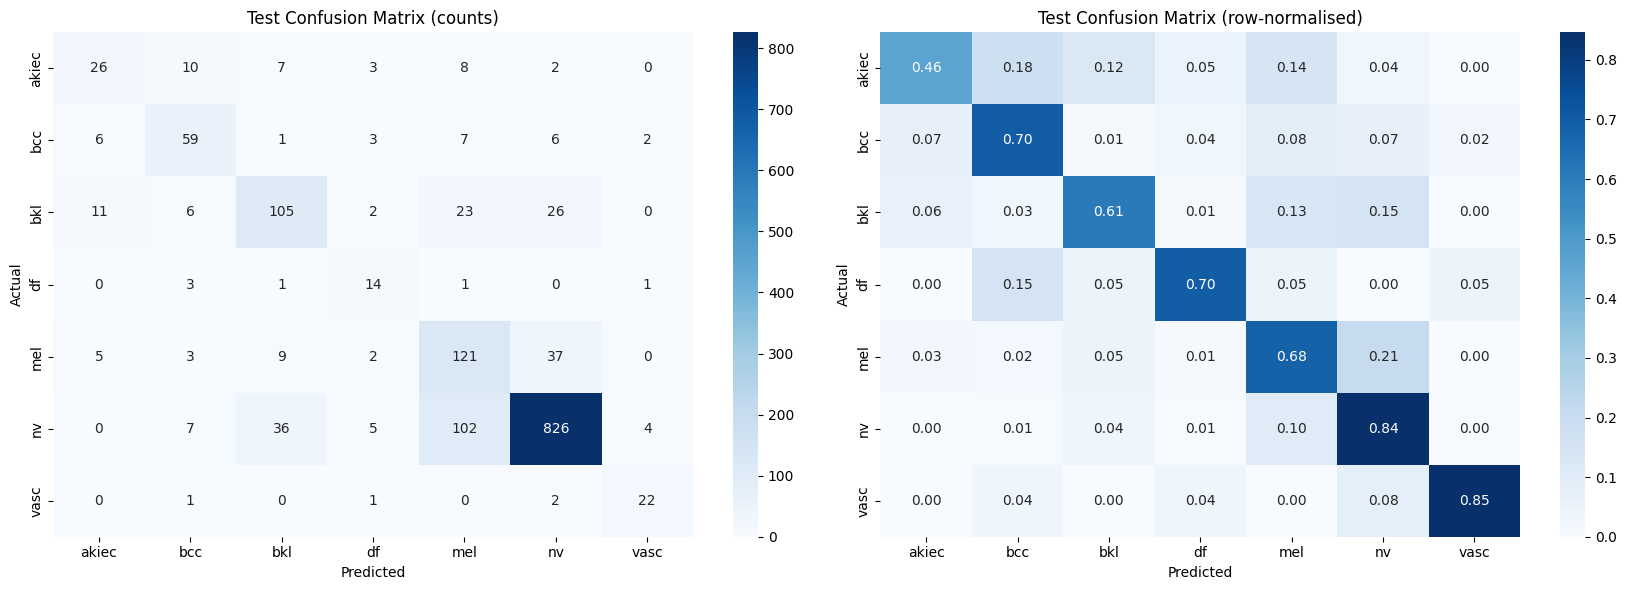

In [29]:
cm_test = np.array(results_test['confusion_matrix'])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Test Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Row-normalised: each row shows where that class's images actually went
cm_norm = cm_test / cm_test.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Test Confusion Matrix (row-normalised)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "test_confusion_matrix.png"), dpi=150)
plt.show()

### 8.2 Error Analysis — Misclassified Melanomas

**What:** Display the melanoma images the model labelled as benign nevi,
alongside its confidence in each wrong prediction.

**Why:** Aggregate metrics say 37 melanomas were missed but not why. Looking
at the actual images shows whether the failures share a visual pattern —
small, faint, or low-contrast lesions — and whether the model was confidently
wrong or merely uncertain. Confident errors are more dangerous than
uncertain ones, and the distinction changes what a deployed system should do
with a prediction.

Melanomas misclassified as nv: 37


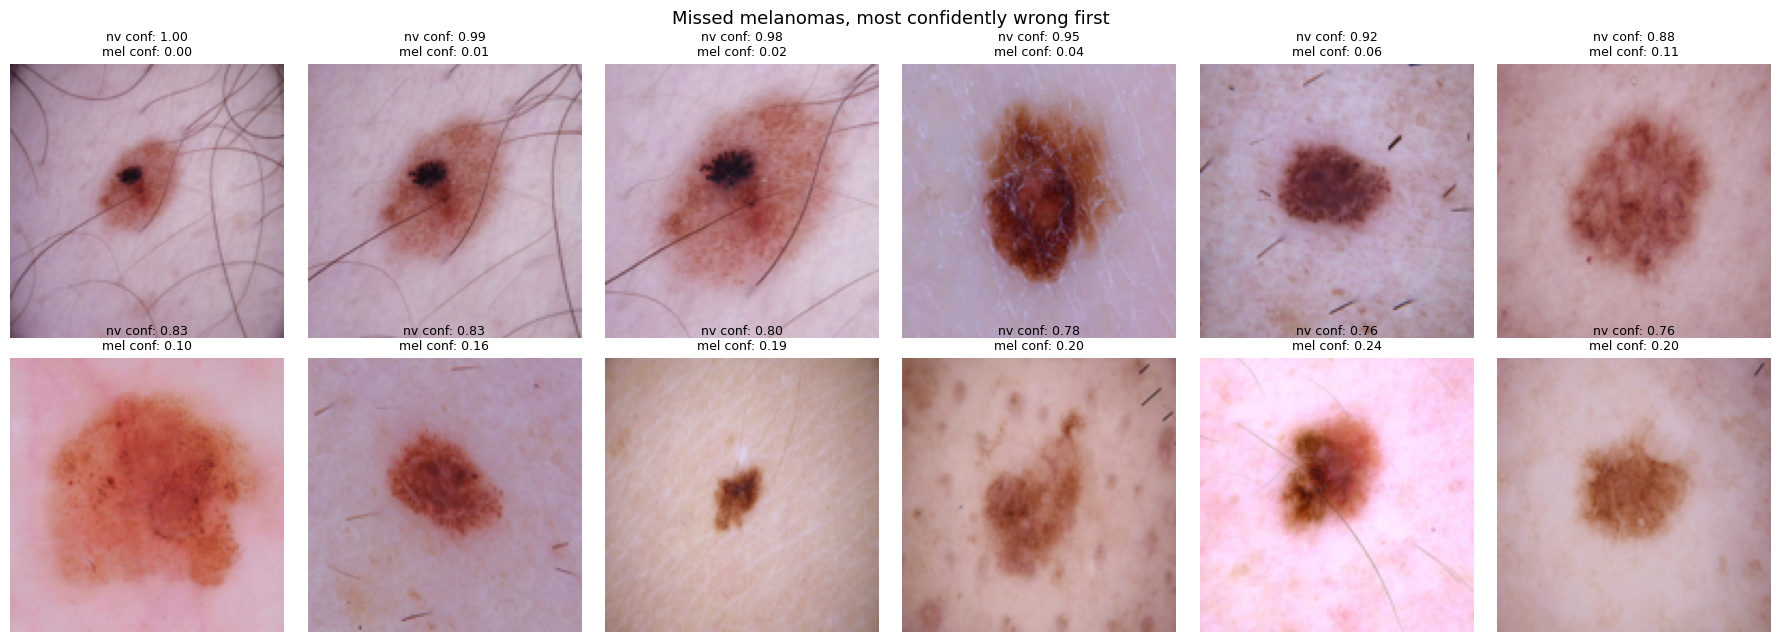


Mean confidence in the wrong nv label: 0.678
Cases where mel was the second choice: 36 of 37


In [30]:
def get_predictions_with_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs = torch.softmax(model(images), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.vstack(all_probs)


y_true_t, probs_t = get_predictions_with_probs(best_model, test_loader)
y_pred_t = probs_t.argmax(1)

MEL, NV = class_to_idx['mel'], class_to_idx['nv']

# Melanomas the model called benign nevi
missed = np.where((y_true_t == MEL) & (y_pred_t == NV))[0]
print(f"Melanomas misclassified as nv: {len(missed)}")

# Sort by the model's confidence in the wrong answer - most confident first
missed_sorted = missed[np.argsort(-probs_t[missed, NV])]

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for ax, idx in zip(axes.flat, missed_sorted[:12]):
    ax.imshow(X_test[idx])
    ax.set_title(f"nv conf: {probs_t[idx, NV]:.2f}\nmel conf: {probs_t[idx, MEL]:.2f}",
                 fontsize=9)
    ax.axis('off')

fig.suptitle("Missed melanomas, most confidently wrong first", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nMean confidence in the wrong nv label: {probs_t[missed, NV].mean():.3f}")
print(f"Cases where mel was the second choice: "
      f"{(probs_t[missed].argsort(1)[:, -2] == MEL).sum()} of {len(missed)}")

### 8.3 Melanoma Threshold Analysis

**What:** Instead of taking the argmax, flag a lesion as melanoma whenever
its melanoma probability exceeds a threshold, and measure how recall and
false alarms trade off as that threshold varies.

**Why:** In 36 of 37 missed melanomas the model ranked mel second — the
signal was present but argmax discarded it. For a triage tool the relevant
question is not "what is the single most likely class" but "is there enough
suspicion to warrant review". Sweeping the threshold quantifies exactly how
many additional melanomas can be caught, and how many false alarms each one
costs.

In [6]:
from torchvision import models

# Reload the best checkpoint
best_model = models.resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 7)
best_model.load_state_dict(torch.load(os.path.join(DRIVE_DIR, "exp4_resnet18_sched.pt")))
best_model = best_model.to(device)


def get_predictions_with_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs = torch.softmax(model(images), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.vstack(all_probs)


y_true_t, probs_t = get_predictions_with_probs(best_model, test_loader)
y_pred_t = probs_t.argmax(1)

MEL, NV = class_to_idx['mel'], class_to_idx['nv']

print("Predictions restored.")
print("  Test accuracy:", round((y_true_t == y_pred_t).mean(), 4))
print("  Should be 0.7737")

Predictions restored.
  Test accuracy: 0.7737
  Should be 0.7737


xNote: the threshold sweep was performed on the test set for illustration.
In a deployed system the operating point must be selected on validation
data, since choosing it on test makes the reported recall optimistic.

In [7]:
mel_probs = probs_t[:, MEL]
is_mel = (y_true_t == MEL)

print(f"{'thresh':>8}{'mel recall':>13}{'caught':>9}{'missed':>9}"
      f"{'false alarms':>15}{'precision':>12}")
print("-" * 68)

for t in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]:
    flagged = mel_probs >= t
    caught = (flagged & is_mel).sum()
    missed_n = (~flagged & is_mel).sum()
    false_alarms = (flagged & ~is_mel).sum()
    recall = caught / is_mel.sum()
    precision = caught / flagged.sum() if flagged.sum() else 0
    print(f"{t:>8.2f}{recall:>13.3f}{caught:>9}{missed_n:>9}"
          f"{false_alarms:>15}{precision:>12.3f}")

print(f"\nFor reference, argmax gives recall "
      f"{(y_pred_t[is_mel] == MEL).mean():.3f} "
      f"({(y_pred_t[is_mel] == MEL).sum()} of {is_mel.sum()})")

  thresh   mel recall   caught   missed   false alarms   precision
--------------------------------------------------------------------
    0.50        0.650      115       62            116       0.498
    0.40        0.695      123       54            154       0.444
    0.30        0.774      137       40            204       0.402
    0.25        0.814      144       33            231       0.384
    0.20        0.864      153       24            271       0.361
    0.15        0.910      161       16            314       0.339
    0.10        0.944      167       10            368       0.312

For reference, argmax gives recall 0.684 (121 of 177)


In [10]:
# ============================================================
# ALL HELPER FUNCTIONS - run once per session
# ============================================================

import random
import json
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, recall_score, precision_score)

RESULTS_DIR = os.path.join(DRIVE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def get_predictions_with_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs = torch.softmax(model(images), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.vstack(all_probs)


def evaluate_full(model, loader, split_name="val"):
    y_true, y_pred = get_predictions(model, loader)
    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    return {
        'split': split_name,
        'accuracy': float((y_true == y_pred).mean()),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'per_class_recall': {c: float(r) for c, r in zip(classes, per_class_recall)},
        'per_class_precision': {c: float(p) for c, p in zip(classes, per_class_precision)},
        'per_class_f1': {c: float(f) for c, f in zip(classes, per_class_f1)},
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }


def log_experiment(exp_id, name, config, results, history=None):
    record = {'exp_id': exp_id, 'name': name, 'config': config,
              'results': results, 'history': history}
    path = os.path.join(RESULTS_DIR, f"exp_{exp_id:02d}_{name}.json")
    with open(path, 'w') as f:
        json.dump(record, f, indent=2)
    print(f"Logged to {path}")
    return record


print("All helpers ready.")

All helpers ready.


In [11]:
results_test = evaluate_full(best_model, test_loader, "test")

log_experiment(
    exp_id=5,
    name="final_test",
    config={
        'model': 'exp4_resnet18_sched.pt',
        'split': 'test',
        'note': 'single evaluation, no tuning on this split',
    },
    results=results_test,
)

print("\nFinal test accuracy:", round(results_test['accuracy'], 4))
print("Final test macro F1:", round(results_test['macro_f1'], 4))

Logged to /content/drive/MyDrive/ham10000_project/results/exp_05_final_test.json

Final test accuracy: 0.7737
Final test macro F1: 0.6579


In [2]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/ham10000_project"
RESULTS_DIR = os.path.join(DRIVE_DIR, "results")

print("Files in results:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(" ", f)

Mounted at /content/drive
Files in results:
  exp_02_weighted_cnn.json
  exp_03_resnet18_weighted.json
  exp_04_resnet18_scheduler.json
  exp_05_final_test.json
  experiments.csv
  mel_threshold_sweep.csv
  test_confusion_matrix.png


In [3]:
import shutil

REPO_DIR = "/content/drive/MyDrive/ham10000_repo"

# Create the folder structure
for sub in ["notebooks", "results/logs", "src"]:
    os.makedirs(os.path.join(REPO_DIR, sub), exist_ok=True)

# Copy results across
for f in ["experiments.csv", "mel_threshold_sweep.csv", "test_confusion_matrix.png"]:
    src = os.path.join(RESULTS_DIR, f)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(REPO_DIR, "results"))
        print("Copied:", f)

for f in os.listdir(RESULTS_DIR):
    if f.startswith("exp_") and f.endswith(".json"):
        shutil.copy(os.path.join(RESULTS_DIR, f),
                    os.path.join(REPO_DIR, "results/logs"))
        print("Copied:", f)

print("\nFolder structure:")
for root, dirs, files in os.walk(REPO_DIR):
    level = root.replace(REPO_DIR, '').count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in sorted(files):
        print("  " * (level + 1) + f)

Copied: experiments.csv
Copied: mel_threshold_sweep.csv
Copied: test_confusion_matrix.png
Copied: exp_02_weighted_cnn.json
Copied: exp_03_resnet18_weighted.json
Copied: exp_04_resnet18_scheduler.json
Copied: exp_05_final_test.json

Folder structure:
ham10000_repo/
  notebooks/
  results/
    experiments.csv
    mel_threshold_sweep.csv
    test_confusion_matrix.png
    logs/
      exp_02_weighted_cnn.json
      exp_03_resnet18_weighted.json
      exp_04_resnet18_scheduler.json
      exp_05_final_test.json
  src/


In [4]:
import json

exp01 = {
    "exp_id": 1,
    "name": "baseline_cnn",
    "config": {
        "architecture": "BaselineCNN (4 conv blocks + global avg pool)",
        "pretrained": False,
        "class_weights": None,
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 32,
        "epochs_run": 20,
        "seed": 42,
        "note": "Logged retrospectively - this run predates the logging helper."
    },
    "results": {
        "split": "val",
        "accuracy": 0.746,
        "macro_f1": 0.411,
        "weighted_f1": 0.709,
        "macro_recall": 0.387,
        "per_class_recall": {
            "akiec": 0.100, "bcc": 0.532, "bkl": 0.355, "df": 0.000,
            "mel": 0.236, "nv": 0.957, "vasc": 0.529
        },
        "per_class_precision": {
            "akiec": 0.286, "bcc": 0.423, "bkl": 0.566, "df": 0.000,
            "mel": 0.600, "nv": 0.801, "vasc": 0.720
        },
        "per_class_f1": {
            "akiec": 0.148, "bcc": 0.471, "bkl": 0.436, "df": 0.000,
            "mel": 0.339, "nv": 0.872, "vasc": 0.610
        },
        "confusion_matrix": [
            [4, 9, 10, 0, 7, 10, 0],
            [4, 41, 7, 0, 0, 23, 2],
            [2, 15, 60, 0, 8, 84, 0],
            [0, 2, 1, 0, 0, 15, 0],
            [4, 10, 12, 0, 39, 98, 2],
            [0, 15, 16, 0, 9, 963, 3],
            [0, 5, 0, 0, 2, 9, 18]
        ]
    },
    "history": None
}

path = os.path.join(REPO_DIR, "results/logs/exp_01_baseline_cnn.json")
with open(path, 'w') as f:
    json.dump(exp01, f, indent=2)

print("Created:", path)
print("\nLogs folder now contains:")
for f in sorted(os.listdir(os.path.join(REPO_DIR, "results/logs"))):
    print(" ", f)

Created: /content/drive/MyDrive/ham10000_repo/results/logs/exp_01_baseline_cnn.json

Logs folder now contains:
  exp_01_baseline_cnn.json
  exp_02_weighted_cnn.json
  exp_03_resnet18_weighted.json
  exp_04_resnet18_scheduler.json
  exp_05_final_test.json
